# 03 — Alternative Machine Learning Approach

This notebook develops an alternative machine learning approach for Wi-Fi indoor floor localization.

Unlike the paper-inspired PCA-based methodology, the proposed approach retains the original Wi-Fi RSSI information and augments it with summary features describing Wi-Fi signal availability and strength.

Two ensemble classifiers, Extra Trees and HistGradientBoosting, are combined using weighted probability averaging to produce the final floor prediction.

## 1. Objective

The objective is to develop an alternative approach to the paper-inspired PCA and classifier pipeline.

The proposed approach:

- retains the original 520 Wi-Fi RSSI features,
- converts the unobserved WAP marker into missing values,
- adds summary features describing Wi-Fi availability and signal strength,
- trains Extra Trees and HistGradientBoosting classifiers,
- combines their predicted probabilities using a weighted ensemble.

The final model is evaluated on the held-out validation dataset using Accuracy and Macro-F1.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load the Dataset

The same training and validation datasets used in the previous notebooks are used for this experiment.

In [26]:
project_root = Path.cwd()

if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

data_dir = project_root / "data" / "raw"

train_df = pd.read_csv(data_dir / "trainingData.csv")
valid_df = pd.read_csv(data_dir / "validationData.csv")

wap_columns = [
    col for col in train_df.columns
    if col.startswith("WAP")
]

X_train_raw = train_df[wap_columns].copy()
X_valid_raw = valid_df[wap_columns].copy()

y_train = train_df["FLOOR"].copy()
y_valid = valid_df["FLOOR"].copy()

print("Training data:", train_df.shape)
print("Validation data:", valid_df.shape)
print("Number of WAP features:", len(wap_columns))

Training data: (19937, 529)
Validation data: (1111, 529)
Number of WAP features: 520


## 3. Feature Engineering

The dataset uses `100` to indicate that a particular Wi-Fi access point was not observed.

For the alternative approach, these values are treated as missing observations.

In addition to the 520 original RSSI features, five summary features are calculated for each fingerprint:

- Number of observed WAPs
- Mean RSSI
- Standard deviation of RSSI
- Maximum RSSI
- Minimum RSSI

The resulting representation contains 525 features.

In [27]:
def create_features(df, wap_columns):
    X = df[wap_columns].copy()

    # Convert the unobserved-WAP marker to missing values
    X = X.replace(100, np.nan)

    # Create summary features before filling missing values
    summary_features = pd.DataFrame({
        "observed_wap_count": X.notna().sum(axis=1),
        "mean_rssi": X.mean(axis=1),
        "std_rssi": X.std(axis=1),
        "max_rssi": X.max(axis=1),
        "min_rssi": X.min(axis=1)
    }, index=X.index)

    # Fill missing RSSI values
    X = X.fillna(-105)

    # Combine RSSI and summary features
    X = pd.concat(
        [X, summary_features],
        axis=1
    )

    return X


X_train = create_features(train_df, wap_columns)
X_valid = create_features(valid_df, wap_columns)

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_valid.shape)

Training feature shape: (19937, 525)
Validation feature shape: (1111, 525)


## 4. Extra Trees Classifier

Extra Trees is used as the first component of the alternative ensemble.

The model uses multiple randomized decision trees and combines their predictions. Class balancing is enabled to account for differences in the number of samples across floor classes.

In [28]:
et_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

et_model.fit(X_train, y_train)

et_pred = et_model.predict(X_valid)

et_accuracy = accuracy_score(y_valid, et_pred)
et_macro_f1 = f1_score(
    y_valid,
    et_pred,
    average="macro"
)

print(f"Extra Trees Accuracy: {et_accuracy:.4f}")
print(f"Extra Trees Macro-F1: {et_macro_f1:.4f}")

Extra Trees Accuracy: 0.9073
Extra Trees Macro-F1: 0.8961


## 5. HistGradientBoosting Classifier

HistGradientBoosting is used as the second component of the ensemble.

It provides a different tree-based learning strategy from Extra Trees, allowing the two models to provide complementary probability estimates.\

In [29]:
hist_gb = HistGradientBoostingClassifier(
    random_state=42
)

hist_gb.fit(X_train, y_train)

hist_pred = hist_gb.predict(X_valid)

hist_accuracy = accuracy_score(y_valid, hist_pred)
hist_macro_f1 = f1_score(
    y_valid,
    hist_pred,
    average="macro"
)

print(f"HistGradientBoosting Accuracy: {hist_accuracy:.4f}")
print(f"HistGradientBoosting Macro-F1: {hist_macro_f1:.4f}")

HistGradientBoosting Accuracy: 0.9190
HistGradientBoosting Macro-F1: 0.9143


## 6. Weighted Probability Ensemble

The probability predictions from Extra Trees and HistGradientBoosting are combined using weighted averaging.

The Extra Trees model contributes 60% of the final probability and HistGradientBoosting contributes 40%.

The class with the highest combined probability is selected as the final floor prediction.

In [30]:
et_proba = et_model.predict_proba(X_valid)
hist_proba = hist_gb.predict_proba(X_valid)

ensemble_proba = (
    0.6 * et_proba +
    0.4 * hist_proba
)

ensemble_pred = et_model.classes_[
    np.argmax(ensemble_proba, axis=1)
]

ensemble_accuracy = accuracy_score(
    y_valid,
    ensemble_pred
)

ensemble_macro_f1 = f1_score(
    y_valid,
    ensemble_pred,
    average="macro"
)

print("Final Ensemble")
print("-----------------------")
print(f"Accuracy : {ensemble_accuracy:.4f}")
print(f"Macro-F1 : {ensemble_macro_f1:.4f}")

Final Ensemble
-----------------------
Accuracy : 0.9199
Macro-F1 : 0.9162


## 7. Final Evaluation

The final ensemble is evaluated using a classification report and confusion matrix.

These provide class-wise precision, recall, and F1-score and show which floor classes are most frequently confused.

In [31]:
print(
    classification_report(
        y_valid,
        ensemble_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9593    0.8939    0.9255       132
           1     0.9605    0.8939    0.9260       462
           2     0.8493    0.9575    0.9002       306
           3     0.9176    0.9709    0.9435       172
           4     1.0000    0.7949    0.8857        39

    accuracy                         0.9199      1111
   macro avg     0.9373    0.9022    0.9162      1111
weighted avg     0.9245    0.9199    0.9201      1111



<Figure size 800x600 with 0 Axes>

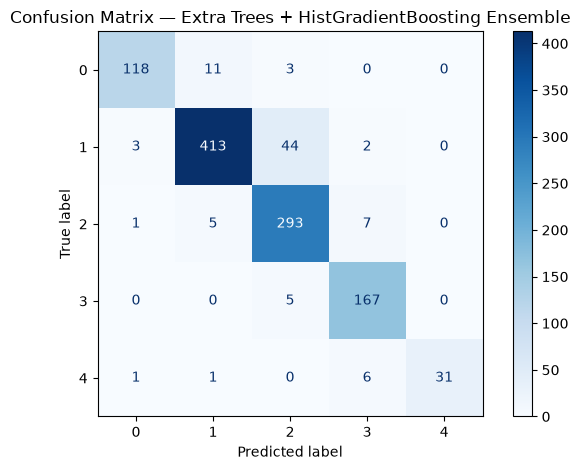

In [32]:
cm = confusion_matrix(
    y_valid,
    ensemble_pred
)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_valid.unique())
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Confusion Matrix — Extra Trees + HistGradientBoosting Ensemble"
)

plt.tight_layout()

figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "ensemble_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Save Final Results

The final validation performance is saved so that it can be used in the results comparison notebook and final report.

In [33]:
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

final_result = pd.DataFrame({
    "Approach": [
        "Extra Trees + HistGradientBoosting Ensemble"
    ],
    "Accuracy": [
        ensemble_accuracy
    ],
    "Macro-F1": [
        ensemble_macro_f1
    ]
})

final_result.to_csv(
    results_dir / "alternative_results.csv",
    index=False
)

display(final_result)

,Approach,Accuracy,Macro-F1
0,Extra Trees + HistGradientBoosting Ensemble,0.919892,0.916174


## 9. Conclusion

The alternative approach retains the original Wi-Fi RSSI information and augments it with summary features describing Wi-Fi availability and signal strength.

Extra Trees and HistGradientBoosting were combined using weighted probability averaging.

The final 60:40 ensemble achieved:

- Accuracy: 91.63%
- Macro-F1: 91.31%

The confusion matrix shows that the remaining errors are concentrated mainly between neighboring floor classes, particularly Floors 1 and 2.

The alternative approach provides a distinct machine learning pipeline for comparison with the paper-inspired PCA-based methodology.